In [2]:
from datasets import load_dataset

c:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
dataset = {}
for data in ['covidqa', 'cuad', 'delucionqa', 'emanual', 'expertqa', 'finqa', 'hagrid', 'hotpotqa', 'msmarco', 'pubmedqa', 'tatqa', 'techqa']:
  dataset[data] = load_dataset("rungalileo/ragbench", data)

In [6]:
dataset

{'finqa': DatasetDict({
     train: Dataset({
         features: ['id', 'question', 'documents', 'response', 'generation_model_name', 'annotating_model_name', 'dataset_name', 'documents_sentences', 'response_sentences', 'sentence_support_information', 'unsupported_response_sentence_keys', 'adherence_score', 'overall_supported_explanation', 'relevance_explanation', 'all_relevant_sentence_keys', 'all_utilized_sentence_keys', 'trulens_groundedness', 'trulens_context_relevance', 'ragas_faithfulness', 'ragas_context_relevance', 'gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score', 'utilization_score', 'completeness_score'],
         num_rows: 12502
     })
     validation: Dataset({
         features: ['id', 'question', 'documents', 'response', 'generation_model_name', 'annotating_model_name', 'dataset_name', 'documents_sentences', 'response_sentences', 'sentence_support_information', 'unsupported_response_sentence_keys', 'adherence_score', 'overall_supported_e

In [23]:
import pandas as pd

df = {}

for dataset_name, dataset_dict in dataset.items():
    df[dataset_name] = {}

    for split_name, dataset in dataset_dict.items():
        df[dataset_name][split_name] = dataset.to_pandas()

In [24]:
df=pd.DataFrame(df)

In [25]:
train_dfs = []

for dataset_name in [
    'covidqa', 'cuad', 'delucionqa', 'emanual', 'expertqa',
    'finqa', 'hagrid', 'hotpotqa', 'msmarco', 'pubmedqa',
    'tatqa', 'techqa'
]:
    for split_name in df[dataset_name].keys():
        train_dfs.append(df[dataset_name][split_name])

train_df = pd.concat(train_dfs, ignore_index=True)

In [26]:
train_df.head()

,id,question,documents,response,generation_model_name,annotating_model_name,dataset_name,documents_sentences,response_sentences,sentence_support_information,...,trulens_groundedness,trulens_context_relevance,ragas_faithfulness,ragas_context_relevance,gpt3_adherence,gpt3_context_relevance,gpt35_utilization,relevance_score,utilization_score,completeness_score
0,358,What role does T-cell count play in severe hum...,[Title: Emergent severe acute respiratory dist...,The T-cell count plays a crucial role in sever...,gpt-3.5-turbo-1106,gpt-4o,covidqa_train,"[[[0a, Title: Emergent severe acute respirator...","[[a, The T-cell count plays a crucial role in ...",[{'explanation': 'This sentence is supported b...,...,NaN,NaN,NaN,NaN,1.0,0.473684,0.368421,0.315789,0.315789,1.00
1,457,What is MVO?,[Title: Gene Knockdowns in Adult Animals: PPMO...,MVO is not defined or mentioned in the provide...,gpt-3.5-turbo-1106,gpt-4o,covidqa_train,"[[[0a, Title: Gene Knockdowns in Adult Animals...","[[a, MVO is not defined or mentioned in the pr...",[{'explanation': 'The sentence correctly state...,...,NaN,NaN,NaN,NaN,0.0,0.529412,0.352941,0.588235,0.588235,1.00
2,1172,What have sero-surveys of MERS virus found?,"[Title: MERS coronavirus: diagnostics, epidemi...",Sero-surveys of MERS virus found no sign of ME...,gpt-3.5-turbo-1106,gpt-4o,covidqa_train,"[[[0a, Title: MERS coronavirus: diagnostics, e...","[[a, Sero-surveys of MERS virus found no sign ...",[{'explanation': 'This sentence is partly supp...,...,NaN,NaN,NaN,NaN,0.0,0.173913,0.086957,0.173913,0.130435,0.75
3,470,How were untreated MDA-MB-231 cells labeled?,[Title: Kinome-Wide siRNA Screening Identifies...,The untreated MDA-MB-231 cells were labeled wi...,gpt-3.5-turbo-1106,gpt-4o,covidqa_train,"[[[0a, Title: Kinome-Wide siRNA Screening Iden...","[[a, The untreated MDA-MB-231 cells were label...",[{'explanation': 'The sentence is fully suppor...,...,NaN,NaN,NaN,NaN,1.0,0.041667,0.041667,0.083333,0.041667,0.50
4,518,What is the number of inhabitants of Reunion I...,[Title: Pandemic Influenza Due to pH1N1/2009 V...,"Reunion Island has a population of 850,000 inh...",gpt-3.5-turbo-1106,gpt-4o,covidqa_train,"[[[0a, Title: Pandemic Influenza Due to pH1N1/...","[[a, Reunion Island has a population of 850,00...",[{'explanation': 'This sentence claims that Re...,...,NaN,NaN,NaN,NaN,1.0,0.055556,0.055556,0.055556,0.055556,1.00


In [27]:
train_df.shape

(95381, 26)

In [28]:
copy_df=train_df.copy()

In [29]:
copy_df.columns

Index(['id', 'question', 'documents', 'response', 'generation_model_name',
       'annotating_model_name', 'dataset_name', 'documents_sentences',
       'response_sentences', 'sentence_support_information',
       'unsupported_response_sentence_keys', 'adherence_score',
       'overall_supported_explanation', 'relevance_explanation',
       'all_relevant_sentence_keys', 'all_utilized_sentence_keys',
       'trulens_groundedness', 'trulens_context_relevance',
       'ragas_faithfulness', 'ragas_context_relevance', 'gpt3_adherence',
       'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score',
       'utilization_score', 'completeness_score'],
      dtype='str')

In [30]:
useless_cols = [
    "id",
    "generation_model_name",
    "annotating_model_name",
    "dataset_name",
    "documents_sentences",
    "response_sentences",
    "unsupported_response_sentence_keys",
    "adherence_score",
    "overall_supported_explanation",
    "relevance_explanation",
    "all_relevant_sentence_keys",
    "all_utilized_sentence_keys",
    "trulens_groundedness",
    "trulens_context_relevance",
    "ragas_faithfulness",
    "ragas_context_relevance",
    "gpt3_adherence",
    "gpt3_context_relevance",
    "gpt35_utilization",
    "relevance_score",
    "utilization_score",
    "completeness_score"
]

copy_df = copy_df.drop(columns=useless_cols)

In [31]:
copy_df.sample(10)

,question,documents,response,sentence_support_information
92141,What do capital leases reflect?,[Off-Balance Sheet Arrangements and Contractua...,"According to the context provided, capital lea...",[{'explanation': 'This sentence is directly su...
58420,Antibiotics for upper respiratory tract infect...,[Data on the use of antibiotics for URIs was e...,Physician specialty may matter when it comes t...,[{'explanation': 'This claim is unsupported. N...
65406,What was the percentage change in the Property...,[The components of the net deferred income tax...,"The Property, plant, and equipment value chang...",[{'explanation': 'The sentence states the valu...
79993,What are the respective share-based compensati...,"[Note 11. Share-Based Compensation [["""", """", ""...",Based on the information provided in the table...,[{'explanation': 'This sentence provides share...
4254,Is there a fee increase or consent requirement...,[Exhibit 10.6 ATTACHMENT A ERCHONIA CORPORATIO...,Based on the information provided in the agree...,[{'explanation': 'The response accurately repo...
45491,The use of nasal packing post rhinoplasty: doe...,[Periorbital edema and ecchymosis following rh...,"Yes, the study mentioned in the provided conte...",[{'explanation': 'This sentence claims that th...
52386,Do Alu repeats drive the evolution of the prim...,[Of all repetitive elements in the human genom...,"Based on the context provided, the evidence su...",[{'explanation': 'This sentence summarizes the...
74440,Which years of Restructuring Plans did the fis...,"[Restructuring and Related Charges [["""", """", ""...","According to the context provided, the fiscal ...",[{'explanation': 'This sentence accurately sta...
6004,Any suggestions about how to release the parki...,[ See the following steps to use the Manual Pa...,"To release the parking brake, pull the lever u...",[{'explanation': 'The sentence that describes ...
11992,what is the ratio of the expected benefit paym...,[mastercard incorporated notes to consolidated...,To find the ratio of the expected benefit paym...,[{'explanation': 'The sentence sets up the con...


In [32]:
copy_df.columns

Index(['question', 'documents', 'response', 'sentence_support_information'], dtype='str')

In [33]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col][0]}")
    print()
    print()

question:What role does T-cell count play in severe human adenovirus type 55 (HAdV-55) infection?


documents:['Title: Emergent severe acute respiratory distress syndrome caused by adenovirus type 55 in immunocompetent adults in 2013: a prospective observational study\nPassage: Recent studies have shown that the immune system plays a crucial role in the clearance of HAdV viremia and survival of the host . Chen et al. reported that, in the acute phase of HAdV-55 infection, patients with severe disease may have high levels of dendritic cells and Th17 cells . In our study, the only patient who recovered from severe infection had higher T-cell counts. Three of the five patients had relatively low T-cell counts when admitted. Our results suggest that these three patients may have been relatively immunocompromised and that a lower T-cell count may be a risk'
 'Title: Emergent severe acute respiratory distress syndrome caused by adenovirus type 55 in immunocompetent adults in 2013: a prospect

In [34]:
copy_df.shape

(95381, 4)

In [35]:
copy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95381 entries, 0 to 95380
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   question                      95381 non-null  str   
 1   documents                     95381 non-null  object
 2   response                      95381 non-null  str   
 3   sentence_support_information  95378 non-null  object
dtypes: object(2), str(2)
memory usage: 59.9+ MB


In [36]:
for num in range(1000):
    if len(copy_df["sentence_support_information"].iloc[num]) >1:
        print(num)
        break

0


In [37]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col].iloc[1]}")
    print()
    print()

question:What is MVO?


documents:['Title: Gene Knockdowns in Adult Animals: PPMOs and Vivo-Morpholinos\nPassage: Global Therapeutics, the cardiology unit of Cook Medical , is developing PPMO-coated stents for balloon angioplasty using PPMOs from AVI BioPharma Inc. The Morpholino moiety targets c-myc to inhibit proliferation of the vascular endothelial cells, which might otherwise cause restenosis.'
 'Title: Gene Knockdowns in Adult Animals: PPMOs and Vivo-Morpholinos\nPassage: Typically the highest antiviral efficacies are achieved with pre-infection administration of the PPMO followed by a series of post-infection doses. Recent studies explicitly comparing effects of unmodified Morpholino oligos and PPMOs show that the PPMOs are far more effective in vivo. Viral applications of PPMOs have recently been reviewed so only a few recent papers applying PPMOs to inhibit viruses will be considered here.'
 'Title: Antigen-specific oncolytic MV-based tumor vaccines through presentation of sel

In [38]:
copy_df["sentence_support_information"].iloc[1]

array([{'explanation': 'The sentence correctly states that MVO is not defined or mentioned in the provided context.', 'fully_supported': True, 'response_sentence_key': 'a', 'supporting_sentence_keys': array(['supported_without_sentence'], dtype=object)},
       {'explanation': 'This sentence suggests that MVO might be a typo for MV (measles virus), which is plausible given that MV is mentioned in Documents 2 and 3.', 'fully_supported': True, 'response_sentence_key': 'b', 'supporting_sentence_keys': array(['2a', '2b', '2c', '2d', '2e', '3a', '3b', '3c', '3d', '3e'],
             dtype=object)}                                                                                                                                                                                                                                                                                                 ,
       {'explanation': 'This sentence generically states that more context is needed for a more accurate answe

In [39]:
import ast
import re
import numpy as np

ARRAY_REGEX = re.compile(r"array\((\[.*?\]),\s*dtype=object\)", re.DOTALL)
DICT_BOUNDARY_REGEX = re.compile(r"}\s*\n\s*{")

def normalize_support_info(support_info):
    if support_info is None:
        return None

    if isinstance(support_info, np.ndarray):
        support_info = support_info.tolist()

    if isinstance(support_info, str):
        support_info = support_info.strip()
        support_info = ARRAY_REGEX.sub(lambda m: m.group(1), support_info)
        support_info = DICT_BOUNDARY_REGEX.sub('} , {', support_info)
        support_info = support_info.replace("\n", " ")
        try:
            support_info = ast.literal_eval(support_info)
        except Exception:
            return None

    if not isinstance(support_info, list):
        return None

    return support_info

def get_grounding_label(row):
    support_info = normalize_support_info(row["sentence_support_information"])
    if not support_info:
        return None

    values = [
        item.get("fully_supported")
        for item in support_info
        if isinstance(item, dict)
    ]
    if len(values) == 0:
        return None

    if all(v is True for v in values):
        return "GROUNDED"
    if any(v is True for v in values):
        return "PARTIALLY_GROUNDED"
    return "HALLUCINATED"


In [40]:
copy_df["label"] = copy_df.apply(get_grounding_label, axis=1)

In [41]:
copy_df["label"].value_counts()

label
GROUNDED              47284
HALLUCINATED          40576
PARTIALLY_GROUNDED     7518
Name: count, dtype: int64

In [42]:
copy_df.isnull().sum()

question                        0
documents                       0
response                        0
sentence_support_information    3
label                           3
dtype: int64

In [43]:
copy_df.columns

Index(['question', 'documents', 'response', 'sentence_support_information',
       'label'],
      dtype='str')

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
copy_df.isnull().sum()

question                        0
documents                       0
response                        0
sentence_support_information    3
label                           3
dtype: int64

In [48]:
copy_df=copy_df.dropna()

In [49]:
copy_df['label'].unique()

<ArrowStringArray>
['GROUNDED', 'PARTIALLY_GROUNDED', 'HALLUCINATED']
Length: 3, dtype: str

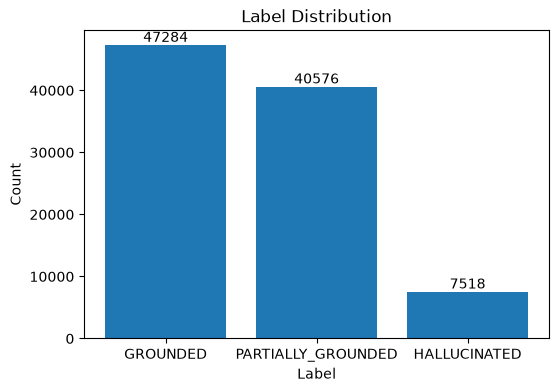

In [50]:
label_counts= copy_df["label"].value_counts()
plt.figure(figsize=(6, 4))
bars=plt.bar(
    ["GROUNDED", "PARTIALLY_GROUNDED","HALLUCINATED"],
    label_counts.values
)
plt.bar_label(bars)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [51]:
for col in copy_df.columns:
    print(f"{col}:{copy_df[col].iloc[3]}")
    print()
    print()

question:How were untreated MDA-MB-231 cells labeled?


documents:['Title: Kinome-Wide siRNA Screening Identifies Src-Enhanced Resistance of Chemotherapeutic Drugs in Triple-Negative Breast Cancer Cells\nPassage: MDA-MB-231 and Hs578T cells were seeded at density of 2 × 10 4 in NanoCulture plates in the presence of 10 nM siRNA. The cells were cultured for 3 days until tumorsphere formation. The tumorsphere were then treated with anticancer drugs for 48 h and stained with Calcein AM and Ethidium homodimer-1 for live and dead cell population, respectively. The cells treated with or without 70% methanol for 30 min were considered as a relative control for all dead or live cells. The live and dead cells were then observed under microscopy and quantitated with Fluoroskan Ascent FL reader as'
 "Title: Testing therapeutics in cell-based assays: Factors that influence the apparent potency of drugs\nPassage: The generation of MDMs has been described in previous studies . Briefly, PBMCs were iso

In [52]:
copy_df.info()

<class 'pandas.DataFrame'>
Index: 95378 entries, 0 to 95380
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   question                      95378 non-null  str   
 1   documents                     95378 non-null  object
 2   response                      95378 non-null  str   
 3   sentence_support_information  95378 non-null  object
 4   label                         95378 non-null  str   
dtypes: object(2), str(3)
memory usage: 62.4+ MB


In [53]:
copy_df["documents"].head().apply(type)

0    <class 'numpy.ndarray'>
1    <class 'numpy.ndarray'>
2    <class 'numpy.ndarray'>
3    <class 'numpy.ndarray'>
4    <class 'numpy.ndarray'>
Name: documents, dtype: object

In [54]:
copy_df.tail()

,question,documents,response,sentence_support_information,label
95376,How to fix the DB2 errors in Portal ? How coul...,[ DIRECT LINKS TO FIXES\n8.0.1.3-WS-BPM-IFJR5...,"Based on the provided context, here are the st...",[{'explanation': 'This introductory sentence o...,HALLUCINATED
95377,How can I get a new authorization code for my ...,[silent install msi TECHNOTE (FAQ)\n\nQUESTION...,The question and context provided do not menti...,[{'explanation': 'This sentence is context set...,HALLUCINATED
95378,"Upgraded to IBM HTTP Server 7.0.0.41, is TLS ...",[ NEWSLETTER\n\nABSTRACT\n The Information Int...,"Based on the information provided, it seems th...",[{'explanation': 'The assertion about the nati...,HALLUCINATED
95379,Is Java 8 supported for BPM? \n\nI understand ...,[ibpma85relnotes; ibpms85relnotes; ibpme85reln...,Based on the information provided in the conte...,[{'explanation': 'This sentence accurately sum...,HALLUCINATED
95380,Non-admin users cannot access webDAV filestore...,[ FIXES ARE AVAILABLE\nFixes integrated in We...,"Based on the provided context, the likely reas...",[{'explanation': 'Supported by Document 3 whic...,HALLUCINATED


In [55]:
copy_df.to_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_data.csv", index=False)